In [18]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
from shapely.geometry import Point
from shapely.geometry import Polygon
from shapely.ops import unary_union
from scipy.ndimage import maximum_filter
import folium
from branca.colormap import linear
import tempfile
import webbrowser
import os

%matplotlib inline

In [3]:
trees = gpd.read_file("/Users/prince/philly-tree-mapper/data/processed/philly_trees_located.geojson").to_crs(4326)
hoods = gpd.read_file("/Users/prince/philly-tree-mapper/data/raw/MUSA_zillow_neighborhoods.geojson").to_crs(4326)


In [27]:
# establish KDE algorith
# Bandwith is smoothing radius, important knob
# Small bandwith -> sharp peaks -> more clusters
# Large bandwith - > smooth peaks -> less, bigger clusters
kde = KernelDensity(kernel="gaussian", bandwidth=3500)

In [4]:
# 6 trees as representatives
# 2 trees w hella acerifolia and rubrum
# 2 trees w mid zie quercus bicolo & sccharinum
# 2 trees with few opacas
acerifolias = trees.loc[trees["scientific_name"] == "Platanus acerifolia"].to_crs(epsg=2272)
acer_rubrums = trees.loc[trees["scientific_name"] == "Acer rubrum"].to_crs(epsg=2272)
quercus_bicolors = trees.loc[trees["scientific_name"] == "Quercus bicolor"].to_crs(epsg=2272)
acer_saccharinums = trees.loc[trees["scientific_name"] == "Acer saccharinum"].to_crs(epsg=2272)
pinus_nigras = trees.loc[trees["scientific_name"] == "Pinus nigra"].to_crs(epsg=2272)
ilex_opacas = trees.loc[trees["scientific_name"] == "Ilex opaca"].to_crs(epsg=2272)


In [11]:
# testing rubrums

# get x y coordinates for each try using list comprehension
rub_coords = np.array([(geom.x, geom.y) for geom in acer_rubrums.geometry])
rub_coords

array([[2724016.82981588,  277065.34481863],
       [2723996.72716317,  277015.0535701 ],
       [2723898.66139785,  276910.60460864],
       ...,
       [2692013.05247313,  242091.07132963],
       [2693928.46955298,  232517.23921613],
       [2731083.08290436,  286397.12938062]], shape=(10320, 2))

In [ ]:
# Store rubrum coords in KDE 
kde.fit(rub_coords)

,"bandwidth bandwidth: float or {""scott"", ""silverman""}, default=1.0The bandwidth of the kernel. If bandwidth is a float, it defines thebandwidth of the kernel. If bandwidth is a string, one of the estimationmethods is implemented.",1500
,"algorithm algorithm: {'kd_tree', 'ball_tree', 'auto'}, default='auto'The tree algorithm to use.",'auto'
,"kernel kernel: {'gaussian', 'tophat', 'epanechnikov', 'exponential', 'linear', 'cosine'}, default='gaussian'The kernel to use.",'gaussian'
,"metric metric: str, default='euclidean'Metric to use for distance computation. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.Not all metrics are valid with all algorithms: refer to thedocumentation of :class:`BallTree` and :class:`KDTree`. Note that thenormalization of the density output is correct only for the Euclideandistance metric.",'euclidean'
,"atol atol: float, default=0The desired absolute tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"rtol rtol: float, default=0The desired relative tolerance of the result. A larger tolerance willgenerally lead to faster execution.",0
,"breadth_first breadth_first: bool, default=TrueIf true (default), use a breadth-first approach to the problem.Otherwise use a depth-first approach.",True
,"leaf_size leaf_size: int, default=40Specify the leaf size of the underlying tree. See :class:`BallTree`or :class:`KDTree` for details.",40
,"metric_params metric_params: dict, default=NoneAdditional parameters to be passed to the tree for use with themetric. For more information, see the documentation of:class:`BallTree` or :class:`KDTree`.",None


In [14]:
# Evaluating density on a grid

# get bounding box grid from rubrum data
x_min, y_min, x_max, y_max = acer_rubrums.total_bounds

# Extend grid by 1 mile so that points on edge of the grid can be evaluated by my buffer
pad = 5280

# create grid over bounding box
# integer at the end of each linspace call determines how many points to make. 
# more points is more computationally expensive, but create higher resolution
# both linspace calls must have same number
xx, yy = np.meshgrid(
    np.linspace(x_min - pad, x_max + pad, 200),
    np.linspace(y_min - pad, y_max + pad, 200),
)

In [15]:
# Get coordinates from the meshgrid you've created
# these coordinates is what KDE uses to calculate density
grid_coords = np.column_stack([xx.ravel(), yy.ravel()])

# calculate point density at each point in the grid by using the data that is already stored in kde
log_density = kde.score_samples(grid_coords)

# turn a logarithmic density back into regular density
# reshapes it to the grid so it can be treated as an image
density = np.exp(log_density).reshape(xx.shape)

In [16]:
# Neighborhood sets the peak detection window.
# cell is only counted as a peak if it is the highest density in a neighborhood x neighborhood patch
# smaller number leads to more peaks
neighborhood = 10
# returns array, each cell is max density in its neighborhood x neighborhood patch
local_max = (density == maximum_filter(density, size=neighborhood))
# Setting this threshold limits peak detection with points that aren't 
# at least one STD above the mean density
threshold = density.mean() + density.std()

# combines both conditions
# to be a real peak you gotta be a local max and above the threshold
peak_mask = local_max & (density > threshold)

# returns the column and row for every cell where both conditions satisfied
peak_rows, peak_cols = np.where(peak_mask)

# returns actual XY coordinates of each cell that satisfied the conditions
cluster_centers = np.column_stack([xx[peak_rows, peak_cols], yy[peak_rows, peak_cols]])


In [17]:
# turn centers into gdf
#first make points in epsg of projected gdf
# turn back into 4326 to project in lat lon
centers_gdf = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in cluster_centers],
    crs=acer_rubrums.crs,    
).to_crs(epsg=4326)

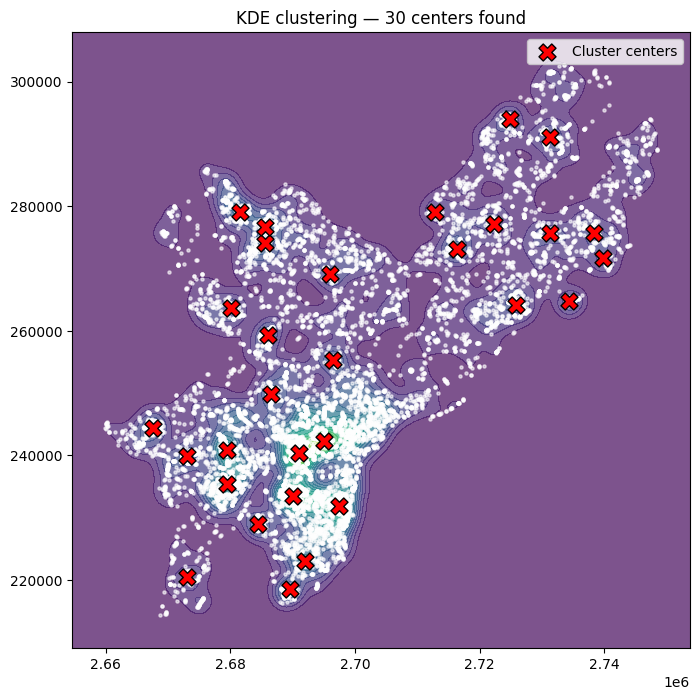

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.contourf(xx, yy, density, levels=20, cmap="viridis", alpha=0.7)
acer_rubrums.plot(ax=ax, color="white", markersize=5, alpha=0.6)
ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
           color="red", s=150, marker="X", edgecolor="black", label="Cluster centers")
ax.set_title(f"KDE clustering — {len(cluster_centers)} centers found")
ax.legend()
plt.show()

In [ ]:
# Getting contour polygons from density surface
# set density threshold to same level as the threshold from the kde
contour_threshold = density.mean() + density.std()

cs = plt.contour(xx, yy, density, levels=[contour_threshold])
polygons = []
for path_collection in cs.allsegs:
    for segment in path_collection:
        if len(segment) >= 4 and np.allclose(segment[0], segment[-1], atol=1e-6) is False:
            segment = np.vstack([segment, segment[0]])
        if len(segment) >= 4:
            poly = Polygon(segment)
            if poly.is_valid and poly.area > 0:
                polygons.append(poly)
plt.close()

In [ ]:
# create function with all this together
def kernel_density(gdf, pad=5280, num_cells=200, hood_size=10, bandwith=3000, kernel="gaussian"):
    kde = KernelDensity(kernel=kernel, bandwidth=bandwith)
    coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
    kde.fit(coords)
    x_min, y_min, x_max, y_max = gdf.total_bounds
    xx, yy = np.meshgrid(
        np.linspace(x_min - pad, x_max + pad, num_cells),
        np.linspace(y_min - pad, y_max + pad, num_cells),
    )
    grid_coords = np.column_stack([xx.ravel(), yy.ravel()])
    log_density = kde.score_samples(grid_coords)
    density = np.exp(log_density).reshape(xx.shape)
    local_max = (density == maximum_filter(density, size=hood_size))
    threshold = density.mean() + density.std()
    peak_mask = local_max & (density > threshold)
    peak_rows, peak_cols = np.where(peak_mask)
    cluster_centers = np.column_stack([xx[peak_rows, peak_cols], yy[peak_rows, peak_cols]])
    centers_gdf = gpd.GeoDataFrame(
        geometry=[Point(xy) for xy in cluster_centers],
        crs=gdf.crs,    
        ).to_crs(epsg=4326)
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.contourf(xx, yy, density, levels=20, cmap="viridis", alpha=0.7)
    gdf.plot(ax=ax, color="white", markersize=5, alpha=0.6)
    ax.scatter(cluster_centers[:, 0], cluster_centers[:, 1],
            color="red", s=150, marker="X", edgecolor="black", label="Cluster centers", alpha=.3)
    ax.set_title(f"KDE clustering — {len(cluster_centers)} centers found")
    ax.legend()
    plt.show()
    pass

In [19]:
def show_in_browser(m):
    """Open a folium map in the default browser without saving to project dir."""
    tmp = tempfile.NamedTemporaryFile(suffix=".html", delete=False)
    tmp.close()
    m.save(tmp.name)
    webbrowser.open(f"file://{tmp.name}")

In [40]:
# create function with kde, cluster -> polygon, and tree points in polygon -> folium map
def density_folium(gdf, pad=5280, num_cells=200, hood_size=10, bandwith=3000, kernel="gaussian"):
    kde = KernelDensity(kernel=kernel, bandwidth=bandwith)
    coords = np.array([(geom.x, geom.y) for geom in gdf.geometry])
    kde.fit(coords)
    x_min, y_min, x_max, y_max = gdf.total_bounds
    xx, yy = np.meshgrid(
        np.linspace(x_min - pad, x_max + pad, num_cells),
        np.linspace(y_min - pad, y_max + pad, num_cells),
    )
    grid_coords = np.column_stack([xx.ravel(), yy.ravel()])
    log_density = kde.score_samples(grid_coords)
    density = np.exp(log_density).reshape(xx.shape)
    local_max = (density == maximum_filter(density, size=hood_size))
    threshold = density.mean() + 2 * density.std()
    peak_mask = local_max & (density > threshold)
    peak_rows, peak_cols = np.where(peak_mask)
    cluster_centers = np.column_stack([xx[peak_rows, peak_cols], yy[peak_rows, peak_cols]])
    centers_gdf = gpd.GeoDataFrame(
        geometry=[Point(xy) for xy in cluster_centers],
        crs=gdf.crs,    
        ).to_crs(epsg=4326)
    # Getting contour polygons from density surface
    # set density threshold to same level as the threshold from the kde

    cs = plt.contour(xx, yy, density, levels=[threshold])
    polygons = []
    for path_collection in cs.allsegs:
        for segment in path_collection:
            if len(segment) >= 4 and np.allclose(segment[0], segment[-1], atol=1e-6) is False:
                segment = np.vstack([segment, segment[0]])
            if len(segment) >= 4:
                poly = Polygon(segment)
                if poly.is_valid and poly.area > 0:
                    polygons.append(poly)
    plt.close()

    # build gdf of cluster polygons
    clusters_gdf = gpd.GeoDataFrame(
        {"cluster_id": range(len(polygons))},
        geometry=polygons,
        crs="EPSG:2272",
    )
    # count points per cluster
    gdf_projected = gdf.to_crs(epsg=2272)

    joined = gpd.sjoin(gdf_projected, clusters_gdf, how="inner", predicate="within")
    counts = joined.groupby("cluster_id").size().rename("point_count")
    clusters_gdf = clusters_gdf.join(counts, on="cluster_id")
    clusters_gdf["point_count"] = clusters_gdf["point_count"].fillna(0).astype(int)
    if len(clusters_gdf) == 0:
        print("No clusters found at this threshold — try lowering it or increasing bandwidth")
        return None
    
    # get ready for folium
    clusters_wgs84 = clusters_gdf.to_crs(epsg=4326)
    points_wgs84 = gdf_projected.to_crs(epsg=4326)

    map_center = [39.95, -75.17]
    m = folium.Map(location=map_center, zoom_start=12, tiles="cartodbpositron")

    colormap = linear.YlOrRd_09.scale(
        clusters_wgs84["point_count"].min(),
        clusters_wgs84["point_count"].max(),
    )
    colormap.caption = "Points per cluster"

    folium.GeoJson(
        clusters_wgs84,
        style_function=lambda feature: {
            "fillColor": colormap(feature["properties"]["point_count"]),
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.5,
        },
        tooltip=folium.GeoJsonTooltip(
            fields=["cluster_id", "point_count"],
            aliases=["Cluster:", "Points:"],
        ),
    ).add_to(m)

    for _, row in points_wgs84.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=2,
            color="navy",
            fill=True,
            fill_opacity=0.6,
        ).add_to(m)

    colormap.add_to(m)
    #m.save("clusters_map.html")
    return m
    

In [41]:
m = density_folium(pinus_nigras, bandwith=300)
show_in_browser(m)